<a href="https://colab.research.google.com/github/pedrocovisi/dados_e_decisoes/blob/main/dados_e_decisoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: Lucca Teodoro Vaz; Número USP: 18119311

---


Nome: Pedro Henrique de Oliveira Covisi; Número USP: 18120543

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
url = 'https://raw.githubusercontent.com/cibelerusso/Datasets/main/DadoseDecisoes.csv'
df = pd.read_csv(url, decimal='.')

In [100]:
df.head()

,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não


# Item a
(a) Inicialmente, classifique os funcionários em dois grupos (Produtividade bin: ”Alta”ou ”Baixa”):

• Alta produtividade: funcionários com produtividade acima da mediana;

• Baixa produtividade: funcionários com produtividade abaixo ou igual à mediana.

In [101]:
median_prod = df['Produtividade'].median()
print(median_prod)

def classificar_produtividade(Produtividade):
    if Produtividade > median_prod:
        return "Alta"
    elif Produtividade <= median_prod:
        return "Baixa"

df['Produtividade_bin'] = df['Produtividade'].apply(classificar_produtividade)

df.head()


87.04


,ID,Idade,Gênero,Departamento,Salário,Horas_Trabalhadas,Produtividade,Satisfação,Tempo_Empresa,Cursos_Realizados,Home_Office,Produtividade_bin
0,1,34,Masculino,RH,3848.89,36,84.89,94.33,0,4,Não,Baixa
1,2,39,Feminino,Vendas,2536.32,48,107.84,98.62,4,9,Sim,Alta
2,3,39,Masculino,Marketing,7377.81,44,95.66,80.23,11,6,Sim,Alta
3,4,27,Feminino,Vendas,2536.32,40,88.89,94.63,8,1,Sim,Alta
4,5,41,Feminino,Vendas,2536.32,37,80.97,86.44,11,12,Não,Baixa


# Item b
(b) Identifique o tipo (quantitativa discreta, quantitativa contínua ou qualitativa nominal ou ordinal) de cada variável do conjunto de dados

## Variaveis:
- Idade: Quantitativa Contínua
- Gênero: Qualitativa Nominal
- Departamento: Qualitativa Nominal
- Salário: Quantitativa Contínua
- Horas Trabalhadas: Quantitativa Contínua
- Produtividade: Quantitativa Contínua
- Satisfação:Quantitativa Contínua
- Tempo de Empresa: Quantitativa Contínua
- Cursos Realizados: Quantitativa Discreta
- Home Office: Qualitativa Nominal
- Produtividade(bin): Qualitativa Ordinal


# Item c
(c) Para analisar variáveis qualitativas, utilize tabelas de frequência, gráficos de barras ou gráficos de setores;


## Análise da distribuição de Funcionários por Departamento


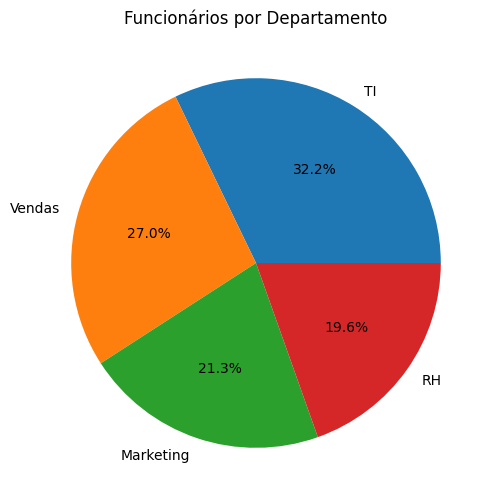

In [102]:
plt.figure(figsize=(8,6))
department_counts = df['Departamento'].value_counts()
plt.pie(
    department_counts,
    labels=department_counts.index,
    autopct='%1.1f%%',
)
plt.title('Funcionários por Departamento')
plt.show()

Do gráfico de pizza podemos inferir, por exemplo, o possível modelo de negócio dessa empresa, que possívelmente está ligada a venda de aparelhos eletrônicos ou de informática e suporte técnico


## Distribuição dos funcionários por Gênero

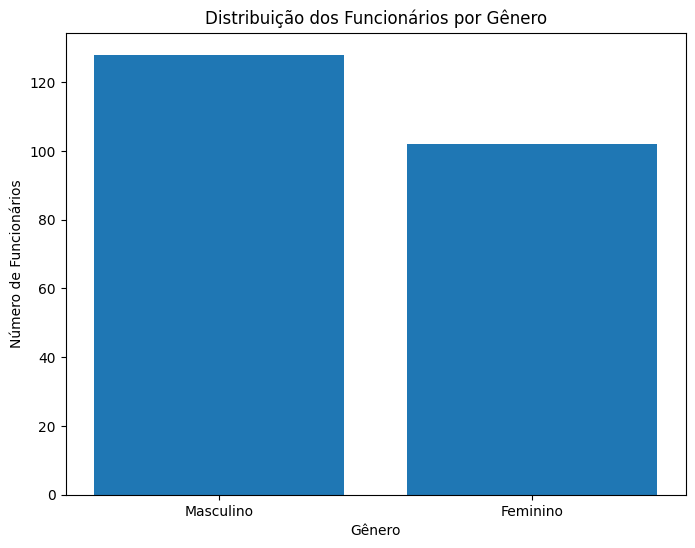

In [103]:
plt.figure(figsize=(8,6))
plt.bar(df['Gênero'].value_counts().index, df['Gênero'].value_counts())
plt.title("Distribuição dos Funcionários por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de Funcionários")
plt.show()

Temos, a partir do gráfico acima, que a distribuição dos fncionários por gênero é bem igualitária. Assim, podemos inferir que a cultura da empresa prioriza a igualdade de gênero (pelo menos na distribuição dos funcionários / Ainda é necessário ver o sálario por gênero, para uma análise inicial mais precisa)


## Distribuição dos funcionários em Home Office

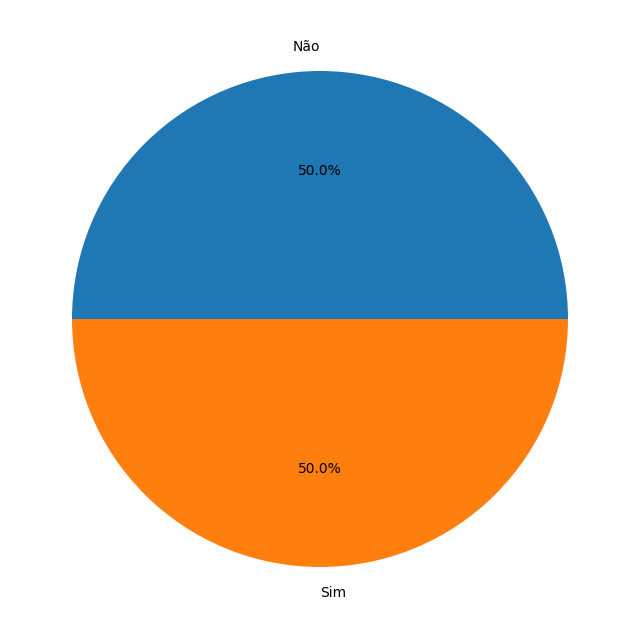

In [104]:
plt.figure(figsize=(8,16))
plt.pie(
  df['Home_Office'].value_counts(),
  labels=df['Home_Office'].value_counts().index,
  autopct='%1.1f%%'
)
plt.show()

Pelo Gráfico acima, interpretamos que a empresa permite um grande número de funcionários no regime online o que demostra o poder de se adaptar da companhia

## Distribuição de funcionários por produtividade

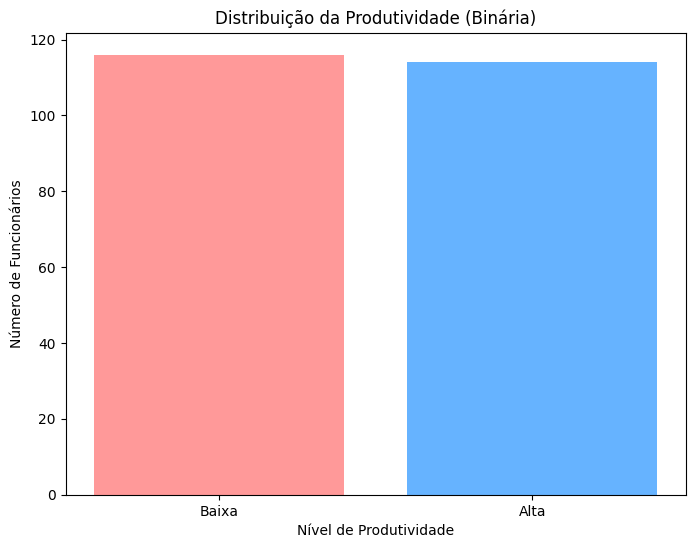

In [105]:
plt.figure(figsize=(8,6))
contagem_prod = df['Produtividade_bin'].value_counts().reindex(['Baixa', 'Alta'])
plt.bar(contagem_prod.index, contagem_prod.values, color=['#ff9999', '#66b3ff'])

plt.title("Distribuição da Produtividade (Binária)")
plt.xlabel("Nível de Produtividade")
plt.ylabel("Número de Funcionários")

plt.show()

Notamos que há um equilíbrio entre funcionários com baixa e alta produtividade. Porém, isso é, na verdade, uma consequência matemática direta da maneira como classificamos a produtividade anteriormente. Pois, ao definirmos a mediana como critério, é evidente que ela irá separar a amostra em duas metades.

# Item d
(d) Para variáveis quantitativas, utilize medidas descritivas e visualizações adequadas (como histogramas, boxplots, gráficos de dispersão ou gráficos de violino);

In [106]:
quantitativas = ['Idade', 'Salário', 'Horas_Trabalhadas', 'Produtividade', 'Satisfação','Tempo_Empresa', 'Cursos_Realizados']
tabela_descritiva = df[quantitativas].describe().round(2).T

print("Medidas Descritivas das Variáveis Quantitativas:")
tabela_descritiva

Medidas Descritivas das Variáveis Quantitativas:


,count,mean,std,min,25%,50%,75%,max
Idade,230.0,30.55,8.22,18.00,24.00,29.00,35.00,54.00
Salário,230.0,8029.97,6556.33,2536.32,2536.32,5667.56,12129.21,29052.82
Horas_Trabalhadas,230.0,38.85,5.82,30.00,34.00,38.00,44.00,48.00
Produtividade,230.0,87.85,12.24,65.74,77.12,87.04,98.42,112.06
Satisfação,230.0,86.15,12.06,39.42,77.57,87.73,96.19,100.00
Tempo_Empresa,230.0,6.77,5.96,0.00,1.00,6.00,11.00,30.00
Cursos_Realizados,230.0,5.20,4.22,0.00,2.00,5.00,8.00,20.00


## Análise de distribuição das varáveis quantitativas

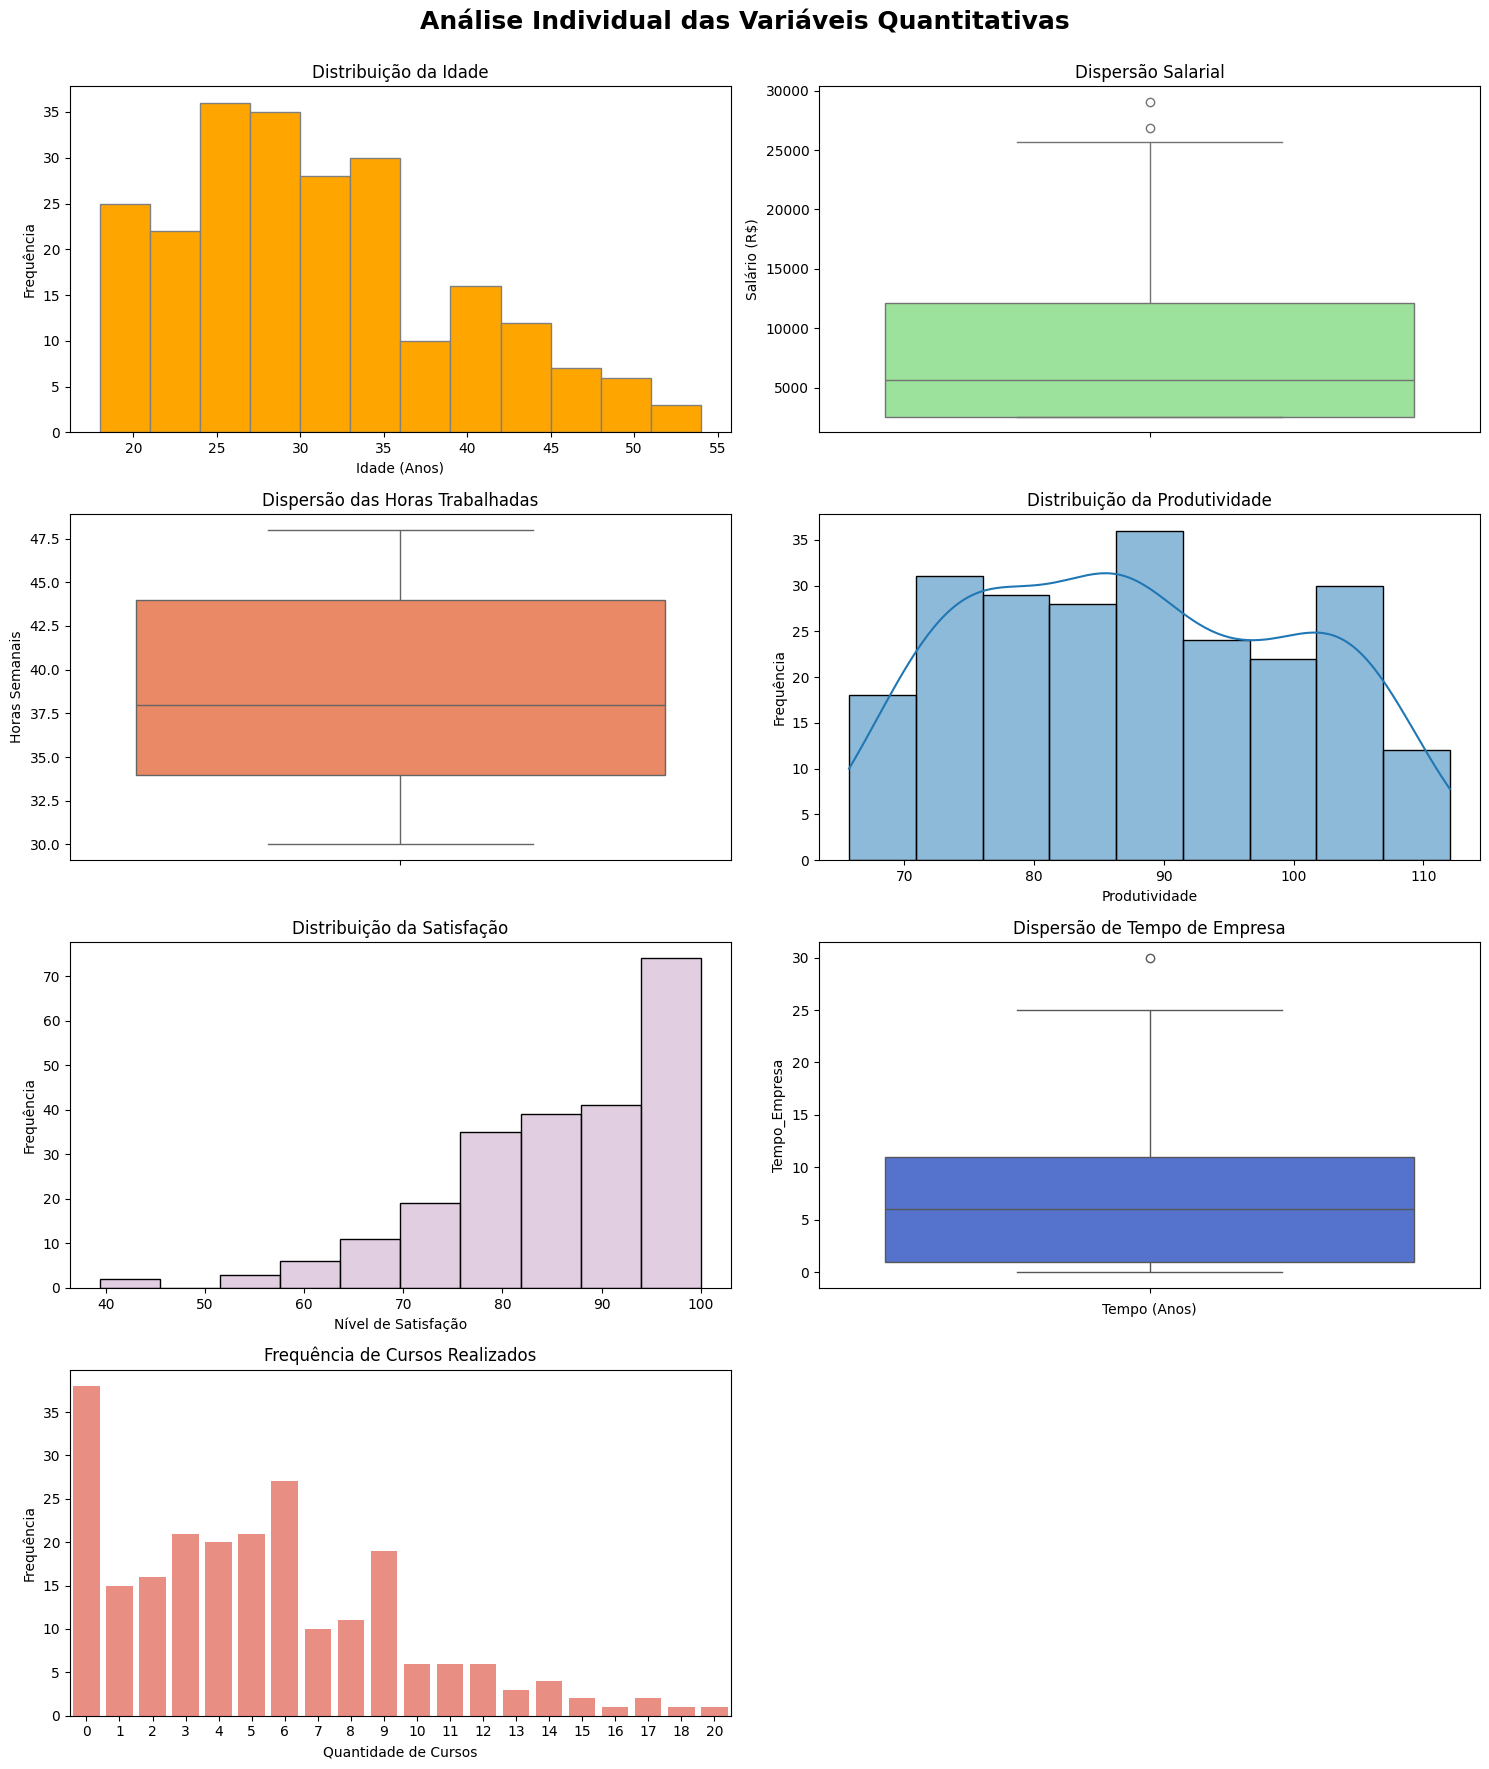

In [107]:
plt.figure(figsize=(15, 18))
plt.suptitle("Análise Individual das Variáveis Quantitativas", fontsize=18, fontweight='bold', y=0.98)

plt.subplot(4, 2, 1)
plt.hist(df['Idade'], bins=12, color='orange', edgecolor='gray')
plt.title('Distribuição da Idade', fontsize=12)
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência')

plt.subplot(4, 2, 2)
sns.boxplot(data=df, y='Salário', color='lightgreen')
plt.title('Dispersão Salarial', fontsize=12)
plt.ylabel('Salário (R$)')

plt.subplot(4, 2, 3)
sns.boxplot(data=df, y='Horas_Trabalhadas', color='coral')
plt.title('Dispersão das Horas Trabalhadas', fontsize=12)
plt.ylabel('Horas Semanais')

plt.subplot(4, 2, 4)
sns.histplot(data=df, x='Produtividade', kde=True)
plt.title('Distribuição da Produtividade', fontsize=12,)
plt.xlabel('Produtividade')
plt.ylabel('Frequência')

plt.subplot(4, 2, 5)
sns.histplot(data=df, x='Satisfação', color = 'thistle')
plt.title('Distribuição da Satisfação', fontsize=12)
plt.xlabel('Nível de Satisfação')
plt.ylabel('Frequência')

plt.subplot(4, 2, 6)
sns.boxplot(data=df, y='Tempo_Empresa',color='royalblue')
plt.title('Dispersão de Tempo de Empresa')
plt.xlabel('Tempo (Anos)')

plt.subplot(4, 2, 7)
sns.countplot(data=df, x='Cursos_Realizados', color='salmon')
plt.title('Frequência de Cursos Realizados', fontsize=12)
plt.xlabel('Quantidade de Cursos')
plt.ylabel('Frequência')

plt.subplot(4, 2, 8).axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Análise das variáveis quantitativas
**1. Idade:** A empresa possui um perfil majoritariamente jovem, com média de idade próxima dos 30 anos mediana de 29 anos, o que significa que metade dos funcionários são mais jovens do que 29 anos.

**2. Salário:** Apresenta uma forte assimetria, com a mediana em torno dos R\$5.600, mas média de mais de R\$8.000, o que evidencia que, existe uma quantidade pequena de funcionários concentrando altas remunerações.

**3. Horas trabalhadas:** Mostra padronização, com média e mediana ambas próximas das 38 horas. A ausência de outliers no boxplot evidencia que não há excessos nem grandes assimetrias nas cargas horárias.

**4. Produtividade:** Apresenta uma distribuição que se aproxima da normalidade, com uma leve assimetria para a esquerda. Alguns funcionários se destacam pela alta ou baixa produtividade, mas no geral, existe uma concentração em valores intermediários.

**5. Satisfação:** Maior concentração de funcionários nos níveis mais altos de satisfação. Apesar disso, existem alguns funcionários distoanto com níveis baixíssimos de satisfação, abaixo dos 40 pontos, o que exige atenção pontual.

**6. Tempo de Empresa:** Metade dos funcionários com até 6 anos de empresa, o que é esperado tendo em vista a baixa idade média dos funcionários. Entretanto, existem excessões e outliers, com até 30 anos de permanência na empresa.

**7. Cursos Realizados:** Quantidade baixa de funcionários com grande número de cursos realizados, apesar disso, a média de 5 cursos por funcionário mostra que a qualificação depende do interesse individual dos funcionários.

## Item e

 e) Construa tabelas resumo e gráficos apropriados para investigar possíveis associações entre a
variável Produtividade bin e as demais variáveis do conjunto de dados;


Para otimizar a visualição desses dados separei a construção dos gráfico em Váriáveis Quantitivas e Qualitativas

# Variaveis Quantitativas

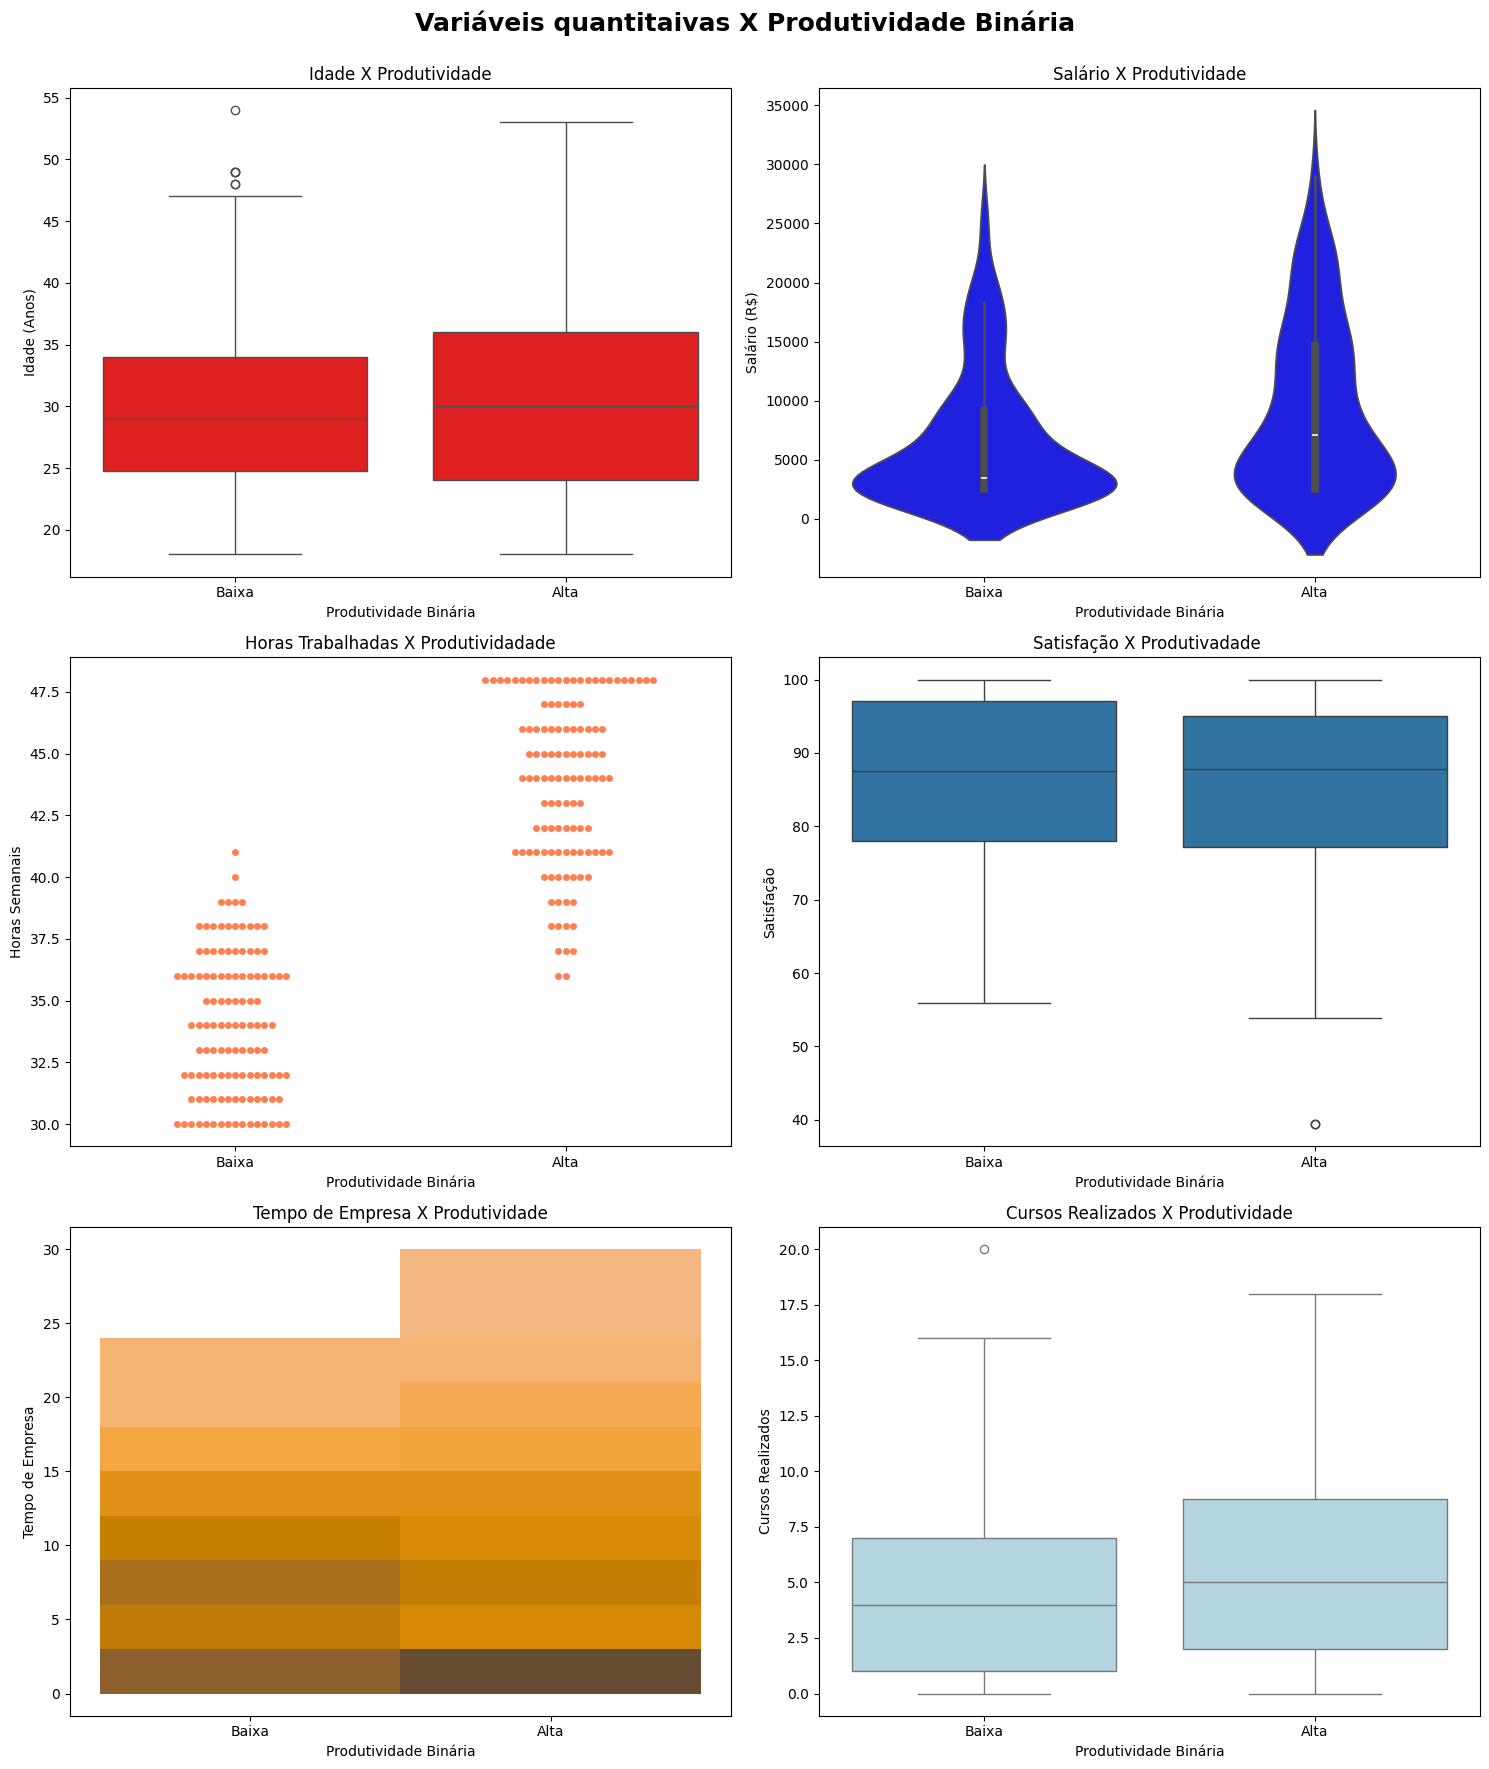

In [108]:
plt.figure(figsize=(15, 18))
plt.suptitle("Variáveis quantitaivas X Produtividade Binária", fontsize=18, fontweight='bold', y=0.98)

# Gráfico Produtividade_bin X Idade
plt.subplot(3, 2, 1)
sns.boxplot(data=df, x='Produtividade_bin', y='Idade', color='red')
plt.title('Idade X Produtividade')
plt.xlabel('Produtividade Binária')
plt.ylabel('Idade (Anos)')

#Gráfico Produtividade_bin X Faixa Salárial
plt.subplot(3, 2, 2)
sns.violinplot(data=df, x='Produtividade_bin', y='Salário', color ='blue')
plt.title('Salário X Produtividade')
plt.ylabel('Salário (R$)')
plt.xlabel('Produtividade Binária')

#Gráfico Produtividade_bin X Horas Trabalhadas
plt.subplot(3, 2, 3)
sns.swarmplot(data=df, x='Produtividade_bin', y='Horas_Trabalhadas', color='coral')
plt.title('Horas Trabalhadas X Produtividadade')
plt.ylabel('Horas Semanais')
plt.xlabel('Produtividade Binária')

#Gráfico Produtividade_bin X Satisfação
plt.subplot(3, 2, 4)
sns.boxplot(data=df, x='Produtividade_bin', y='Satisfação')
plt.title('Satisfação X Produtivadade ')
plt.xlabel('Produtividade Binária')
plt.ylabel('Satisfação')

# Gráfico Produtividade e Tempo de Empresa
plt.subplot(3,2,5)
sns.histplot( data =df, x='Produtividade_bin', y='Tempo_Empresa', color = 'Orange')
plt.title('Tempo de Empresa X Produtividade' )
plt.xlabel('Produtividade Binária')
plt.ylabel('Tempo de Empresa')

# Gráfico Produtividade e Cursos Realizados
plt.subplot(3,2,6)
sns.boxplot( data =df, x='Produtividade_bin', y='Cursos_Realizados', color = 'LightBlue')
plt.title('Cursos Realizados X Produtividade' )
plt.xlabel('Produtividade Binária')
plt.ylabel('Cursos Realizados')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

  # Variáveis Qualitativas

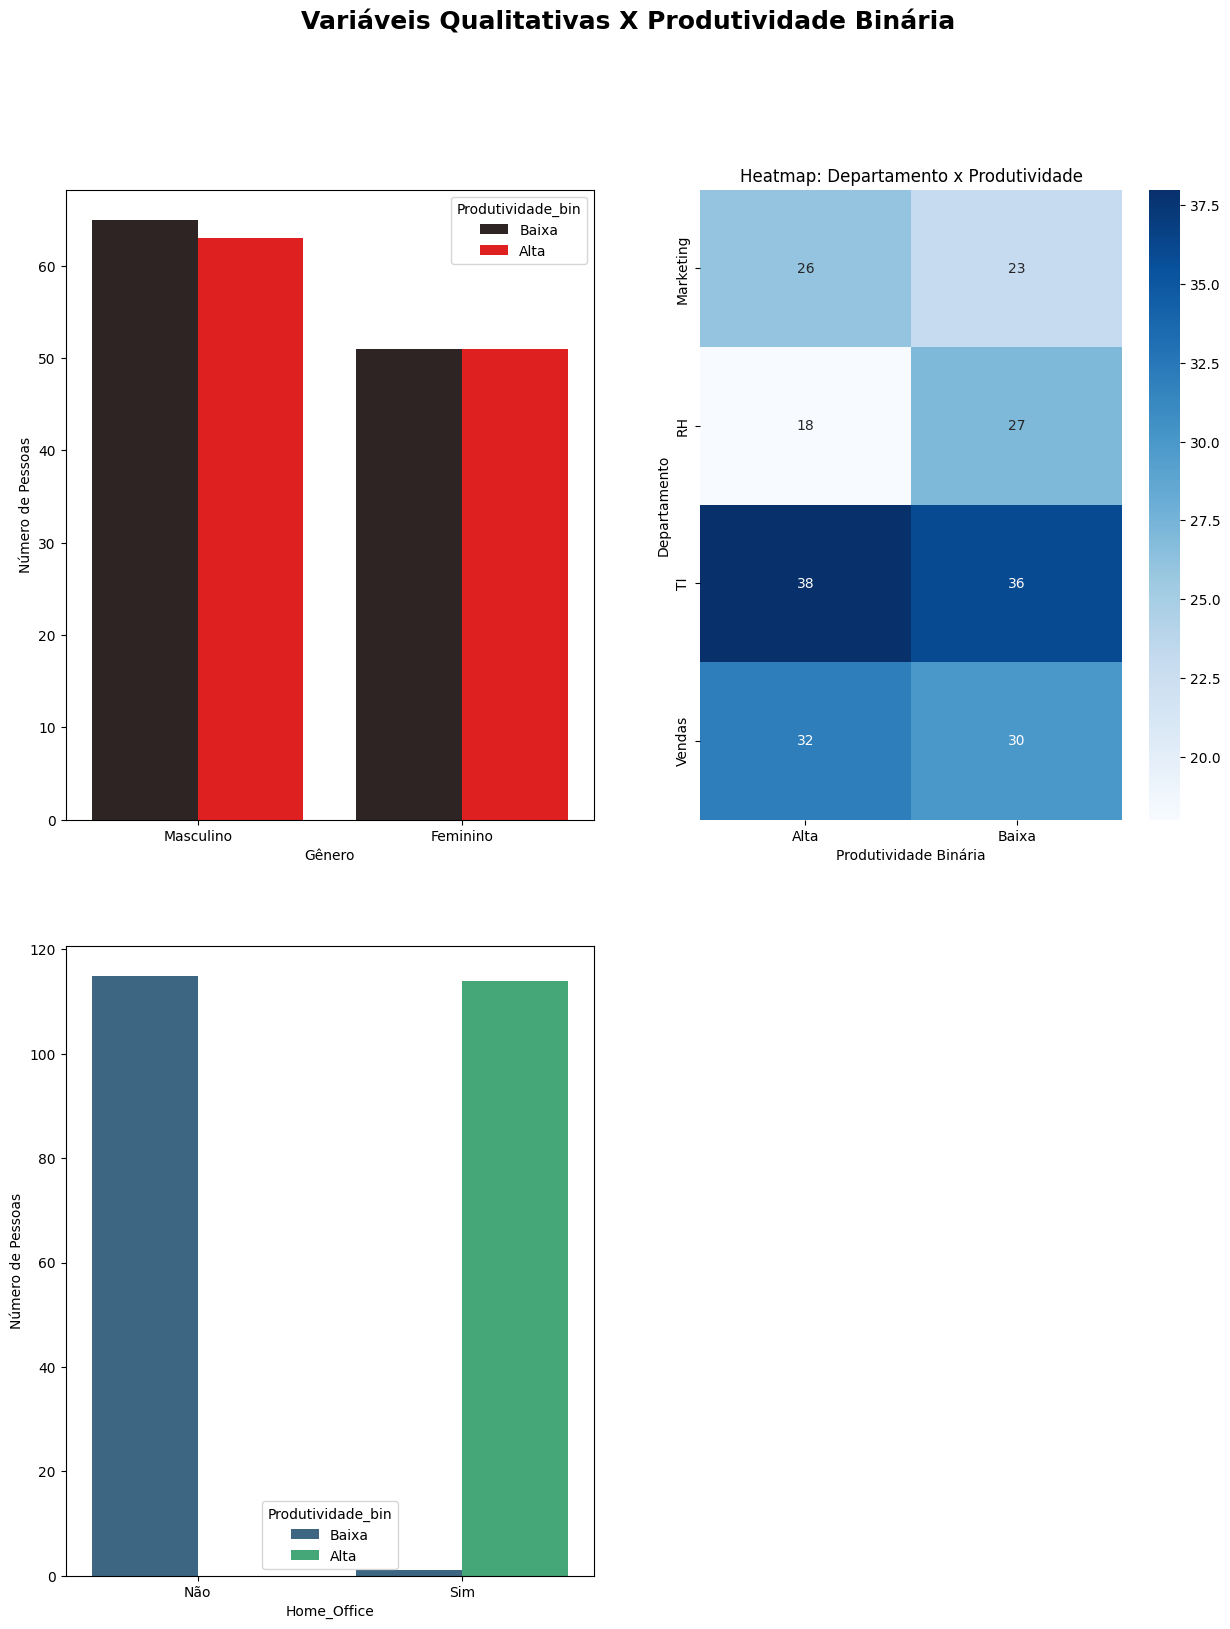

In [109]:
plt.figure(figsize=(15, 18))
plt.suptitle("Variáveis Qualitativas X Produtividade Binária", fontsize=18, fontweight='bold', y=0.98)

#Genero Masculino
plt.subplot(2,2,1)
sns.countplot(data=df, x='Gênero',hue='Produtividade_bin', palette='dark:red')
plt.ylabel("Número de Pessoas")

#Departamento
plt.subplot(2,2,2)
tabela_freq = pd.crosstab(df['Departamento'], df['Produtividade_bin'])
sns.heatmap(tabela_freq, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap: Departamento x Produtividade')
plt.ylabel('Departamento')
plt.xlabel('Produtividade Binária')

#Home Ofiice
plt.subplot(2,2,3)
sns.countplot(data=df, x='Home_Office',hue='Produtividade_bin',palette='viridis')
plt.ylabel("Número de Pessoas")


plt.show()

In [110]:
display(df.groupby('Produtividade_bin')[['Idade', 'Salário', 'Horas_Trabalhadas', 'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados']].mean().round(2))

display(pd.crosstab(df['Gênero'], df['Produtividade_bin']))
display(pd.crosstab(df['Departamento'], df['Produtividade_bin']))
display(pd.crosstab(df['Home_Office'], df['Produtividade_bin']))

,Idade,Salário,Horas_Trabalhadas,Satisfação,Tempo_Empresa,Cursos_Realizados
Produtividade_bin,,,,,,
Alta,30.82,9527.15,43.79,85.50,6.83,5.51
Baixa,30.28,6558.61,34.00,86.79,6.72,4.91


Produtividade_bin,Alta,Baixa
Gênero,,
Feminino,51,51
Masculino,63,65


Produtividade_bin,Alta,Baixa
Departamento,,
Marketing,26,23
RH,18,27
TI,38,36
Vendas,32,30


Produtividade_bin,Alta,Baixa
Home_Office,,
Não,0,115
Sim,114,1


In [111]:
variaveis = ['Idade', 'Salário', 'Horas_Trabalhadas', 'Satisfação', 'Tempo_Empresa', 'Cursos_Realizados']
display(df.groupby('Produtividade_bin')[variaveis].describe().round(2).T)

Produtividade_bin            Alta     Baixa
Idade             count    114.00    116.00
                  mean      30.82     30.28
                  std        8.14      8.32
                  min       18.00     18.00
                  25%       24.00     24.75
                  50%       30.00     29.00
                  75%       36.00     34.00
                  max       53.00     54.00
Salário           count    114.00    116.00
                  mean    9527.15   6558.61
                  std     7149.99   5564.00
                  min     2536.32   2536.32
                  25%     2536.32   2536.32
                  50%     7125.84   3485.34
                  75%    14636.74   9167.80
                  max    29052.82  25677.80
Horas_Trabalhadas count    114.00    116.00
                  mean      43.79     34.00
                  std        3.37      2.87
                  min       36.00     30.00
                  25%       41.00     31.75
                  50%       44.00     34.00
                  75%       47.00     36.00
                  max       48.00     41.00
Satisfação        count    114.00    116.00
                  mean      85.50     86.79
                  std       12.90     11.19
                  min       39.42     55.95
                  25%       77.14     78.05
                  50%       87.82     87.57
                  75%       95.05     97.10
                  max      100.00    100.00
Tempo_Empresa     count    114.00    116.00
                  mean       6.83      6.72
                  std        6.50      5.40
                  min        0.00      0.00
                  25%        1.00      2.00
                  50%        6.00      6.00
                  75%       11.00     10.25
                  max       30.00     23.00
Cursos_Realizados count    114.00    116.00
                  mean       5.51      4.91
                  std        4.17      4.26
                  min        0.00      0.00
                  25%        2.00      1.00
                  50%        5.00      4.00
                  75%        8.75      7.00
                  max       18.00     20.00

## Análise da correlação entre Produtividade_Bin com outras variáveis.

**Idade:** A faixa etária é similiar entre os funcionários com alta produtividade e os funcionários com baixa produtividade. Observando os gráficos, as medianas e a amplitude interquartil das idades se sobrepõem consideravelmente. Isso indica de forma exploratória que a variável Idade, de forma isolada, não possui forte associação com o nível de produtividade.

**Salário:** Tanto os funcionários de alta quanto os de baixa produtividade têm seus salários concentrados nas faixas mais baixas. Salários fora do comum e muito altos aparecem em ambos os lados. A distribuição em violino evidencia forte assimetria à direita para ambos os grupos. A presença de outliers com salários altíssimos também no grupo de Baixa produtividade indica que uma remuneração excepcionalmente alta não é garantia de alta produtividade.

**Horas Trabalhadas:** O grupo de alta produtividade mostra cargas horárias majoritariamente maiores do que o grupo com baixa produtividade.

**Satisfação:** Não há discrepâncias evidentes entre os grupos de alta e baixa produtividade.

**Tempo de Empresa:** Independente da produtividade, a maior parte da equipe está concentrada na região com pouco tempo de empresa. Apesar disso, alguns profissionais com mais anos de trabalho na empresa.

**Cursos Realizados:** Há um número levemente superior de cursos realizados entre funcionários com alta produtividade.

**Gênero:** Tanto no grupo feminino, quanto no masculino, há um equilíbrio entre funcionários com alta e baixa produtividade. A proporção analisada mostra uma relação próxima de 50/50 em ambos os gêneros, sugerindo que o fator gênero não influencia a probabilidade do funcionário pertencer ao grupo de alta ou baixa produtividade.

**Departamento:** Vemos que alguns departamentos como o Marketing, o TI e as Vendas têm uma quantidade de funcionários de alta produtividade maior do que os de baixa produtividade, enquanto o RH é o único no qual a quantidade de funcionários classificados no grupo com baixa produtividade.

**Home Office:** Há uma grande discrepância, pois quase todos os funcionários que trabalham em Home Office tem alta produtividade, enquanto os que trabalham presencialmente tem baixa produtividade.

# Item f

(f) Investigue, de forma exploratória, se funcionários com alta ou baixa produtividade também são
os que:
• trabalham mais horas;
• possuem maior satisfação;
• permanecem mais tempo na empresa;
• realizam mais cursos;
• atuam em determinados departamentos;
• trabalham em regime de home-office.

## Análise Exploratória de produtividade.

**Trabalham mais horas:**
Sim. Há uma diferença notória na carga horária. Funcionários classificados com Alta produtividade trabalham 44 horas semanais, em média, enquanto os de baixa bpodutividade trabalham cerca de 34 horas. Há uma correlação positiva entre horas trabalhadas e produtividade.

**Possuem maior satisfação:**
Não. Os níveis de satisfação são praticamente idênticos entre os dois grupos. Em ambos, as médias giram em torno de 86 pontos, com distribuições muito parecidas.

**Permanecem mais tempo na empresa:**
Não. O tempo de trabalho na empresa é similar em ambos os grupos, com médias entre 6,7 e 6,8 anos e mediana em 6 para ambos os grupos.

**Realizam mais cursos:**
Sim. O grupo de alta produtividade possui uma tendência ligeiramente superior na qualificação, com média de 5,5 cursos contra 4,9 do grupo de Baixa. A diferença não é drástica, mas sinaliza uma associação positiva moderada.

**Atuam em determinados departamentos:**
Parcialmente. Vendas, Marketing e TI apresentam uma proporção maior de funcionários com Alta Produtividade. O departamento de Recursos Humanos (RH) é a principal exceção, sendo o único onde o número de funcionários de Baixa Produtividade (27) excede o de Alta Produtividade (18).

**Trabalham em regime de Home Office:**
Sim. Esta é a variável qualitativa que apresenta a maior disparidade. Quase todos os funcionários na modalidade de Home Office estão enquadrados no grupo de alta produtividade, enquanto quse todos os que trabalham na modalidade presencial ficam no grupo de baixa produtividade.

# Item g


Descreva quais variáveis parecem apresentar associação mais forte com a produtividade (binária)
e justifique sua conclusão com base nas evidências obtidas;

## Associações com Produtividade (binária)

Como já foi analisado anteriormente, as duas variáveis que apresentaram maior associação com a produtividade foram:

**1. Home Office:** Variável com a maior associação isoladamente. Quase todos os indivíduos da amostra que pertencem ao grupo de alta produtividade atuam no Home Office e quase todos os que pertencem ao grupo de baixa produtividade trabalham presencialmente. Essa associação contradiz o que é esperado pela maior parte das empresas, que frequentemente pressupõem que a presencialidade garante maior rendimento.

**2. Horas Trabalhadas:** Dentre as variáveis numéricas, esta foi a única que apresentou uma distinção clara entre os perfis. Observando o gráfico de swarmplot e as tabelas de dados, notamos que não há sobreposição notável entre os grupos de alta e baixa produtividade. Assim, é possível concluir que os funcinários classificados no grupo de alta produtividade cumprem cargas horárias significativamente maiores (com média próxima a 44h semanais) em relação aos funcinários classificados no grupo de baixa produtividade (média em torno de 34h semanais).

# Item h


(h) Discuta possíveis limitações dessa análise exploratória, destacando por que associações observadas não necessariamente possuem significância estatística. Indique quais seriam as análises
complementares para a análise confirmatória e quais seriam as suas implicações.

## Limitações da análise exploratória e análises complementares necessárias.

A Análise Exploratória de Dados (AED) possui limitações inerentes ao seu método, pois se baseia exclusivamente na observação de padrões e medidas descritivas de uma amostra.

Apesar de encontrarmos associações, isso não garante que essas diferenças não sejam fruto do acaso e tenham, de fato, uma relação de causa e consequência.

Além disso, não temos controle de outras variáveis que não foram observadas na amostra de dados analisada.

Para superar essas limitações, o passo seguinte seria conduzir uma Análise Confirmatória. Onde todas os fatores seriam isolados para prover um embasamento estatisticamente seguro na tomada de decisões gerenciais.